Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Game Title                   10 non-null     str    
 1   Release Year                 10 non-null     int64  
 2   Developer                    10 non-null     str    
 3   Publisher                    10 non-null     str    
 4   Genre                        10 non-null     str    
 5   Platform(s)                  10 non-null     str    
 6   metacritic_score             10 non-null     int64  
 7   estimated_sales_in_millions  10 non-null     float64
 8   ESRB Rating                  10 non-null     str    
 9   Avg. Playtime (Hours)        10 non-null     int64  
dtypes: float64(1), int64(3), str(6)
memory usage: 932.0 bytes
None

First few rows:
                    Game Title  Release Year         Developer  \
0        Red Dead Redemption 2          2018  Ro

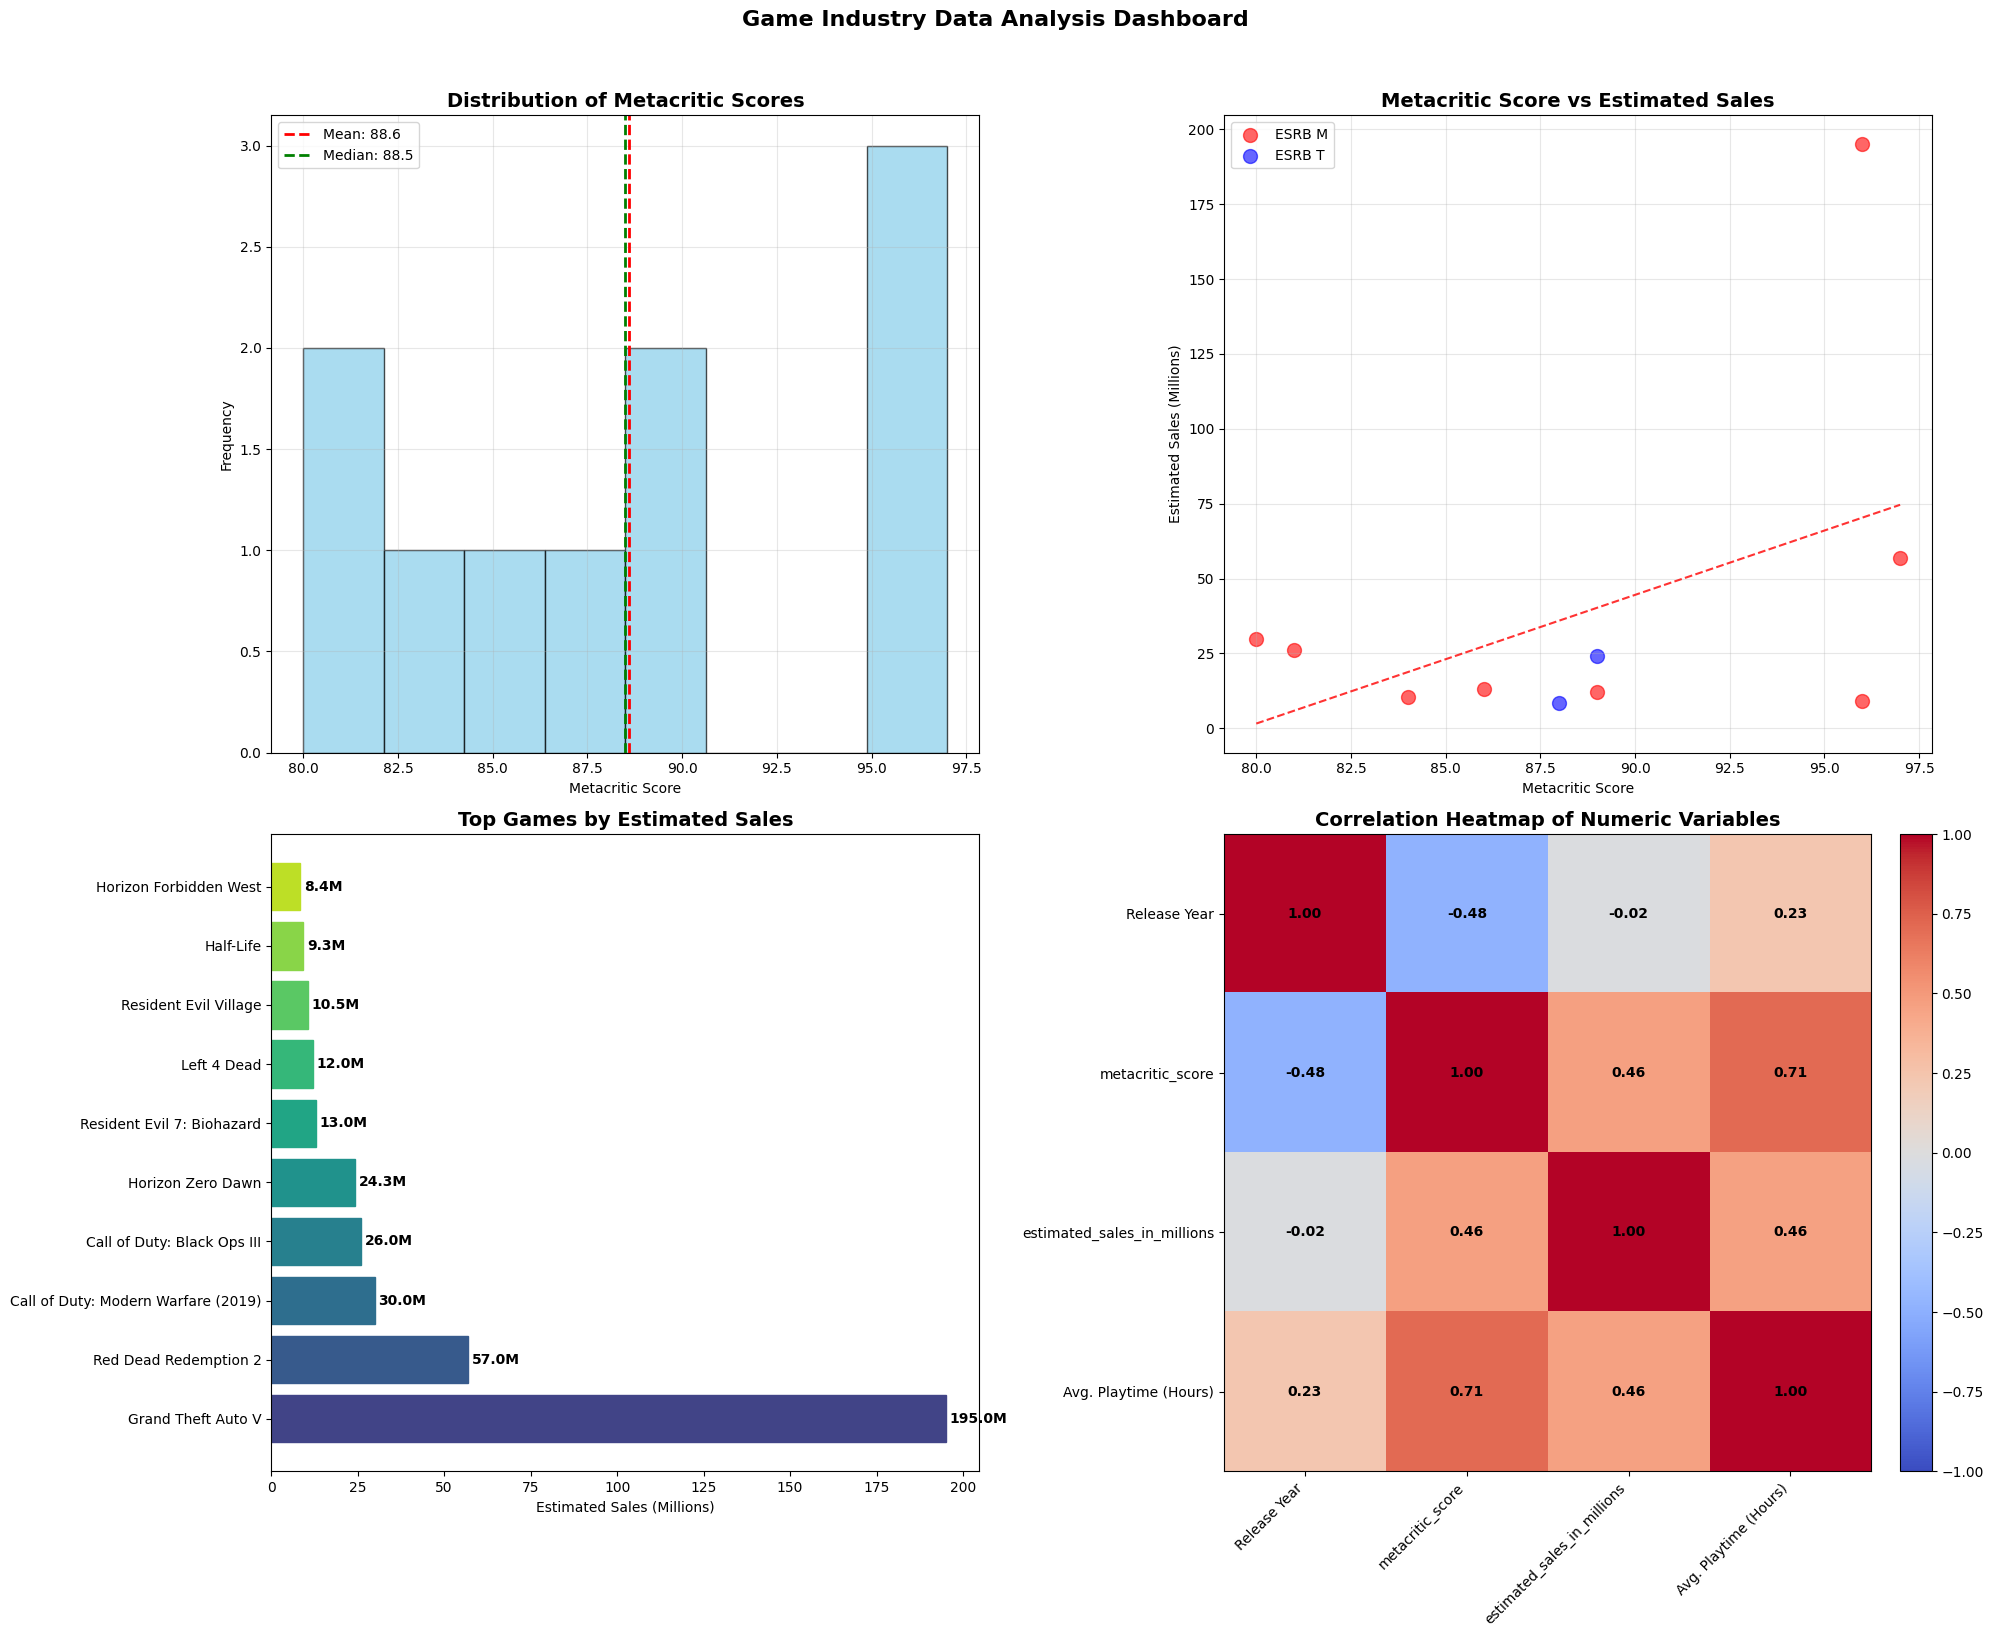


SUMMARY STATISTICS

Metacritic Scores:
Mean: 88.60
Median: 88.50
Std Dev: 6.15
Min: 80
Max: 97

Estimated Sales (Millions):
Total: 385.50M
Mean: 38.55M
Median: 18.65M
Max: 195.0M (Grand Theft Auto V)

Average Playtime (Hours):
Mean: 19.0h
Range: 6h - 50h


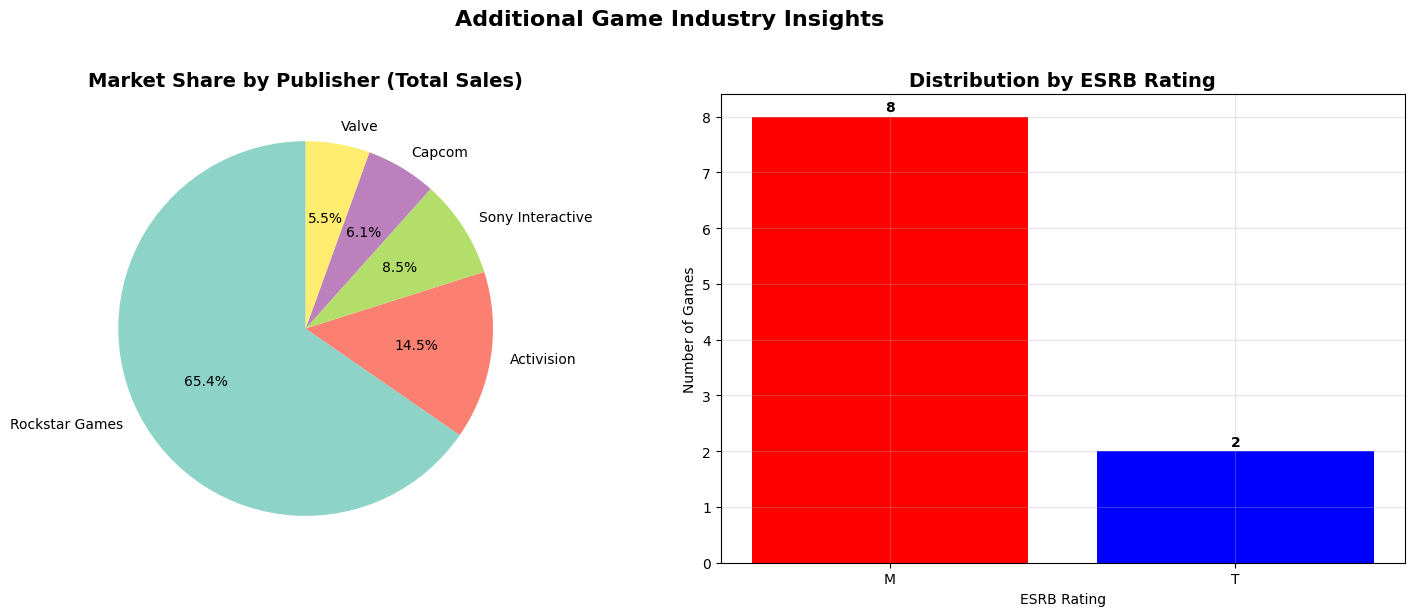

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

df = pd.read_excel('AIDS-1EXP3.xlsx')

print("Dataset Info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())
print("\nColumn names:")
print(df.columns.tolist())

fig = plt.figure(figsize=(20, 16))

ax1 = plt.subplot(2, 2, 1)
ax1.hist(df['metacritic_score'], bins=8, color='skyblue', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Metacritic Score')
ax1.set_ylabel('Frequency')
ax1.set_title('Distribution of Metacritic Scores', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

mean_score = df['metacritic_score'].mean()
median_score = df['metacritic_score'].median()
ax1.axvline(mean_score, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_score:.1f}')
ax1.axvline(median_score, color='green', linestyle='dashed', linewidth=2, label=f'Median: {median_score:.1f}')
ax1.legend()

ax2 = plt.subplot(2, 2, 2)

colors = {'M': 'red', 'T': 'blue'}
for rating in df['ESRB Rating'].unique():
    mask = df['ESRB Rating'] == rating
    ax2.scatter(df[mask]['metacritic_score'], 
               df[mask]['estimated_sales_in_millions'],
               c=colors[rating], 
               label=f'ESRB {rating}',
               s=100, 
               alpha=0.6)

ax2.set_xlabel('Metacritic Score')
ax2.set_ylabel('Estimated Sales (Millions)')
ax2.set_title('Metacritic Score vs Estimated Sales', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

z = np.polyfit(df['metacritic_score'], df['estimated_sales_in_millions'], 1)
p = np.poly1d(z)
ax2.plot(df['metacritic_score'].sort_values(), 
         p(df['metacritic_score'].sort_values()), 
         "r--", alpha=0.8, label='Trend Line')

ax3 = plt.subplot(2, 2, 3)
top_games = df.nlargest(10, 'estimated_sales_in_millions')

bars = ax3.barh(range(len(top_games)), top_games['estimated_sales_in_millions'].values)
ax3.set_yticks(range(len(top_games)))
ax3.set_yticklabels(top_games['Game Title'].values, fontsize=10)
ax3.set_xlabel('Estimated Sales (Millions)')
ax3.set_title('Top Games by Estimated Sales', fontsize=14, fontweight='bold')

for i, (bar, sales) in enumerate(zip(bars, top_games['estimated_sales_in_millions'].values)):
    ax3.text(sales + 1, bar.get_y() + bar.get_height()/2, f'{sales:.1f}M', 
             va='center', fontweight='bold')

colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_games)))
for bar, color in zip(bars, colors):
    bar.set_color(color)

ax4 = plt.subplot(2, 2, 4)

numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()


im = ax4.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)


for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        text = ax4.text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                       ha="center", va="center", color="black", fontweight='bold')

ax4.set_xticks(range(len(correlation_matrix.columns)))
ax4.set_yticks(range(len(correlation_matrix.columns)))
ax4.set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
ax4.set_yticklabels(correlation_matrix.columns)
ax4.set_title('Correlation Heatmap of Numeric Variables', fontsize=14, fontweight='bold')

plt.colorbar(im, ax=ax4, fraction=0.046, pad=0.04)

plt.suptitle('Game Industry Data Analysis Dashboard', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("SUMMARY STATISTICS")
print("="*50)
print("\nMetacritic Scores:")
print(f"Mean: {df['metacritic_score'].mean():.2f}")
print(f"Median: {df['metacritic_score'].median():.2f}")
print(f"Std Dev: {df['metacritic_score'].std():.2f}")
print(f"Min: {df['metacritic_score'].min()}")
print(f"Max: {df['metacritic_score'].max()}")

print("\nEstimated Sales (Millions):")
print(f"Total: {df['estimated_sales_in_millions'].sum():.2f}M")
print(f"Mean: {df['estimated_sales_in_millions'].mean():.2f}M")
print(f"Median: {df['estimated_sales_in_millions'].median():.2f}M")
print(f"Max: {df['estimated_sales_in_millions'].max()}M (Grand Theft Auto V)")

print("\nAverage Playtime (Hours):")
print(f"Mean: {df['Avg. Playtime (Hours)'].mean():.1f}h")
print(f"Range: {df['Avg. Playtime (Hours)'].min()}h - {df['Avg. Playtime (Hours)'].max()}h")

fig2, axes = plt.subplots(1, 2, figsize=(15, 6))

publisher_sales = df.groupby('Publisher')['estimated_sales_in_millions'].sum().sort_values(ascending=False)
axes[0].pie(publisher_sales.values, labels=publisher_sales.index, autopct='%1.1f%%', 
            startangle=90, colors=plt.cm.Set3(np.linspace(0, 1, len(publisher_sales))))
axes[0].set_title('Market Share by Publisher (Total Sales)', fontsize=14, fontweight='bold')

esrb_counts = df['ESRB Rating'].value_counts()
axes[1].bar(esrb_counts.index, esrb_counts.values, color=['red', 'blue'])
axes[1].set_xlabel('ESRB Rating')
axes[1].set_ylabel('Number of Games')
axes[1].set_title('Distribution by ESRB Rating', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

for i, count in enumerate(esrb_counts.values):
    axes[1].text(i, count + 0.1, str(count), ha='center', fontweight='bold')

plt.suptitle('Additional Game Industry Insights', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

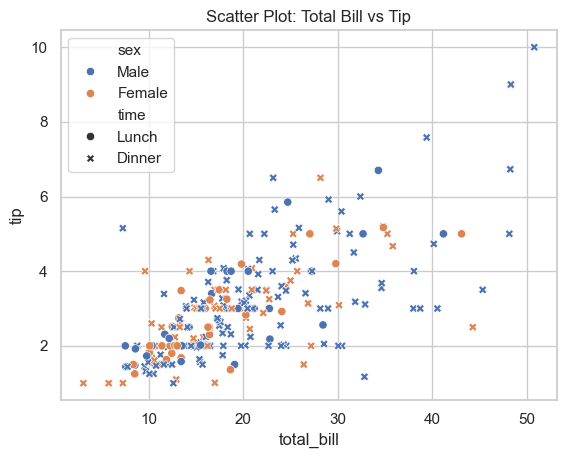

In [2]:
plt.figure()
sns.scatterplot(
    data=df,
    x="total_bill",
    y="tip",
    hue="sex",
    style="time"
)
plt.title("Scatter Plot: Total Bill vs Tip")
plt.show()

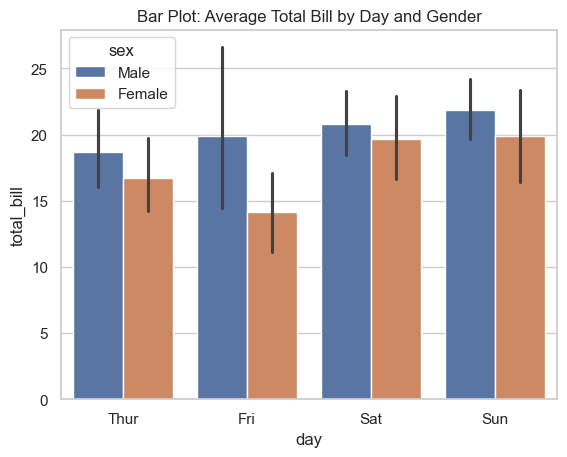

In [3]:
plt.figure()
sns.barplot(
    data=df,
    x="day",
    y="total_bill",
    hue="sex"
)
plt.title("Bar Plot: Average Total Bill by Day and Gender")
plt.show()

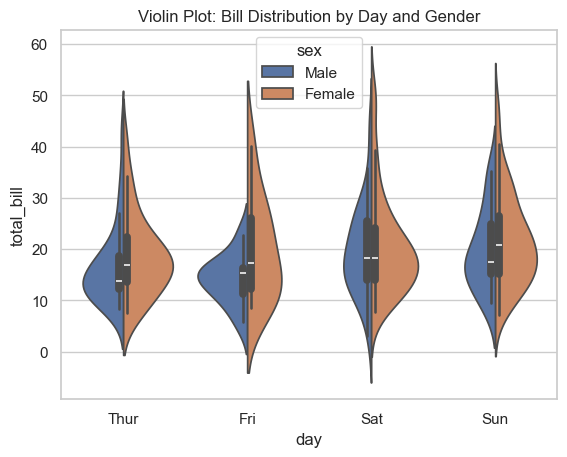

In [3]:
plt.figure()
sns.violinplot(
    data=df,
    x="day",
    y="total_bill",
    hue="sex",
    split=True
)
plt.title("Violin Plot: Bill Distribution by Day and Gender")
plt.show()

In [4]:
corr = df.corr(numeric_only=True)
corr

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


In [ ]:
plt.figure()
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)
plt.title("Heatmap: Correlation Matrix")
plt.show()

In [ ]:
plt.figure()
sns.swarmplot(
    data=df,
    x="day",
    y="total_bill"
)
plt.title("Swarm Plot: Total Bill by Day")
plt.show()